# 01 · Handling Missing Data (Imputation Techniques)

        > Part of the **Data Preprocessing** module — taught alongside the `data/customer_churn.csv` dataset.

        ## Learning objectives
        - Detect and quantify missing values in a real dataset
- Distinguish MCAR, MAR, and MNAR — and why the type matters
- Apply mean / median / mode, KNN, and iterative (MICE) imputation
- Add a *missingness indicator* and understand when to keep one
- Choose the right strategy per column — not one-size-fits-all

        ---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

df = pd.read_csv("data/customer_churn.csv")
print("shape:", df.shape)
df.head()

shape: (5000, 15)


,customer_id,age,gender,city,education,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_products,has_credit_card,is_active_member,estimated_salary,churned
0,10000,46.0,Male,Bengaluru,Bachelors,40,Month-to-month,Electronic check,16.90,686.72,3,1,0,55083.68,1
1,10001,28.0,Female,Chennai,Masters,22,One year,Credit card,88.73,NaN,2,1,0,75325.39,0
2,10002,52.0,Female,Mumbai,Bachelors,7,Two year,Mailed check,67.45,449.61,1,1,1,57584.71,0
3,10003,54.0,Male,Delhi,Bachelors,31,One year,Bank transfer,48.61,1615.53,1,1,0,57525.63,0
4,10004,18.0,Male,Delhi,Bachelors,18,Month-to-month,Bank transfer,90.82,1612.81,1,1,0,103508.09,0


## 1. Detect missing values

Always start by *measuring* the problem. `isna().sum()` per column gives the count;
dividing by `len(df)` gives the fraction — a more useful number for deciding strategy.

In [5]:
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": df.isna().mean().round(3) * 100,
    "dtype": df.dtypes,
})
missing[missing["n_missing"] > 0].sort_values("pct_missing", ascending=False)

,n_missing,pct_missing,dtype
age,400,8.0,float64
estimated_salary,300,6.0,float64
total_charges,259,5.2,float64
education,150,3.0,str


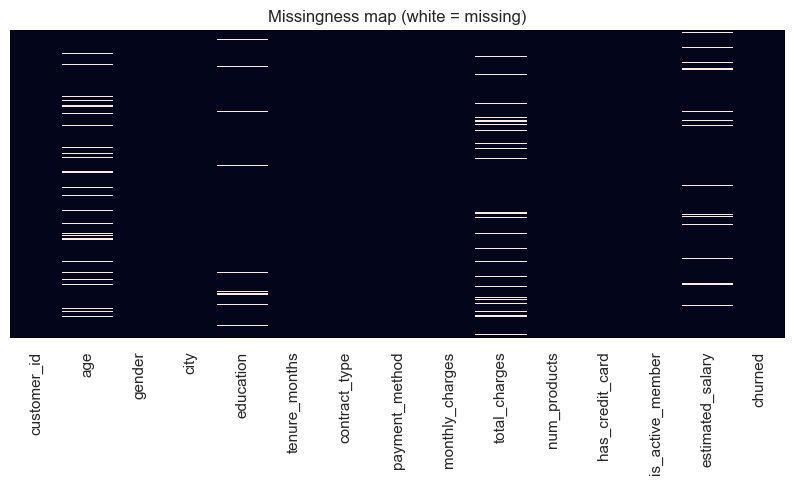

In [3]:
# Visual map of missingness — useful for spotting patterns across rows
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title("Missingness map (white = missing)")
plt.show()

## 2. MCAR vs MAR vs MNAR

| Type | Meaning | Example |
|------|---------|---------|
| **MCAR** | Missing completely at random | Sensor randomly drops a reading |
| **MAR**  | Missingness depends on *other observed* columns | `total_charges` missing because `tenure_months == 0` |
| **MNAR** | Missingness depends on the *missing value itself* | High earners refuse to disclose salary |

MCAR is safest to drop. MAR can usually be imputed well using other features.
MNAR is the dangerous one — imputation will be biased; sometimes you need a separate model
or a *missingness indicator* feature.

In [18]:
# Quick MAR check: is total_charges missing more often for new customers?
df.assign(missing_total=df["total_charges"].isna()) \
  .groupby(df["tenure_months"] == 0)["churned"].count() \
  .rename(index={True: "tenure==0", False: "tenure>0"})

print("Missing rate when tenure==0:",
      df.loc[df["tenure_months"] == 0, "total_charges"].isna().mean().round(3))
print("Missing rate when tenure>0 :",
      df.loc[df["tenure_months"] >  0, "total_charges"].isna().mean().round(3))

Missing rate when tenure==0: 1.0
Missing rate when tenure>0 : 0.04


## 3. Strategy 1 — Drop

Dropping is fine when missingness is small (<5%) **and** MCAR. It is wrong when the
missingness itself is informative.

In [5]:
print("Original rows:", len(df))
print("After dropna() :", len(df.dropna()))
print("Lose:", df.isna().any(axis=1).mean().round(3), "of rows")

Original rows: 5000
After dropna() : 3976
Lose: 0.205 of rows


## 4. Strategy 2 — Simple imputation (mean / median / mode)

- **Mean** — for symmetric numeric columns
- **Median** — for skewed numeric columns or when outliers exist
- **Mode** — for categorical columns

Always **fit the imputer on the training set only**, then transform both train and test.
Doing it on the whole dataframe leaks information.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X = df.drop(columns=["customer_id", "churned"])
y = df["churned"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
###################################
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

median_imp = SimpleImputer(strategy="median")
mode_imp   = SimpleImputer(strategy="most_frequent")

X_train_num = pd.DataFrame(median_imp.fit_transform(X_train[num_cols]),
                           columns=num_cols, index=X_train.index)
X_train_cat = pd.DataFrame(mode_imp.fit_transform(X_train[cat_cols]),
                           columns=cat_cols, index=X_train.index)

X_train_num.isna().sum().sum(), X_train_cat.isna().sum().sum()

(np.int64(0), np.int64(0))

## 5. Strategy 3 — KNN imputation

Fills a missing value using the *k* nearest rows (by the other features). Captures
relationships between columns that mean/median can't. Pricier to compute, but often
much more accurate when features are correlated.

In [7]:
from sklearn.impute import KNNImputer

knn_imp = KNNImputer(n_neighbors=5)
X_train_knn = pd.DataFrame(
    knn_imp.fit_transform(X_train[num_cols]),
    columns=num_cols, index=X_train.index,
)
X_train_knn[num_cols].describe().round(2)

,age,tenure_months,monthly_charges,total_charges,num_products,has_credit_card,is_active_member,estimated_salary
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,41.83,35.81,65.60,2311.63,1.62,0.70,0.55,73405.45
std,12.16,21.05,28.12,1614.83,0.81,0.46,0.50,46557.35
min,18.00,0.00,10.00,0.00,1.00,0.00,0.00,15000.00
25%,34.00,18.00,50.52,954.86,1.00,0.00,0.00,56497.91
50%,41.00,36.00,64.42,2082.99,1.00,1.00,1.00,70113.61
75%,49.00,54.00,79.13,3383.03,2.00,1.00,1.00,85017.28
max,87.00,72.00,467.84,9222.64,4.00,1.00,1.00,896230.97


## 6. Strategy 4 — Iterative imputation (MICE-style)

Models each column with missing values as a regression on the others, iterating until
convergence. The most flexible option for numeric data.

In [8]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

mice = IterativeImputer(max_iter=10, random_state=0)
X_train_mice = pd.DataFrame(
    mice.fit_transform(X_train[num_cols]),
    columns=num_cols, index=X_train.index,
)
X_train_mice[num_cols].describe().round(2)

,age,tenure_months,monthly_charges,total_charges,num_products,has_credit_card,is_active_member,estimated_salary
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,41.97,35.81,65.60,2306.69,1.62,0.70,0.55,73432.35
std,12.10,21.05,28.12,1622.34,0.81,0.46,0.50,46267.36
min,18.00,0.00,10.00,-1198.14,1.00,0.00,0.00,15000.00
25%,34.00,18.00,50.52,955.84,1.00,0.00,0.00,56850.32
50%,42.00,36.00,64.42,2088.31,1.00,1.00,1.00,72036.32
75%,49.00,54.00,79.13,3394.46,2.00,1.00,1.00,84801.50
max,87.00,72.00,467.84,9222.64,4.00,1.00,1.00,896230.97


## 7. Bonus — Missingness indicator

Sometimes *the fact that a value is missing* is itself predictive (think: a customer who
didn't fill in salary may behave differently). Add a binary `_was_missing` column before
imputing and let the model decide if it's useful.

In [9]:
train = X_train.copy()
for col in ["age", "total_charges", "estimated_salary"]:
    train[f"{col}_was_missing"] = train[col].isna().astype(int)

train.filter(like="_was_missing").mean().round(3)

age_was_missing                 0.076
total_charges_was_missing       0.051
estimated_salary_was_missing    0.058
dtype: float64

## 8. Compare strategies side-by-side

Same column (`age`) imputed three different ways. Look at the resulting distributions —
mean/median imputation creates a **spike** at the imputed value; KNN/MICE preserve shape.

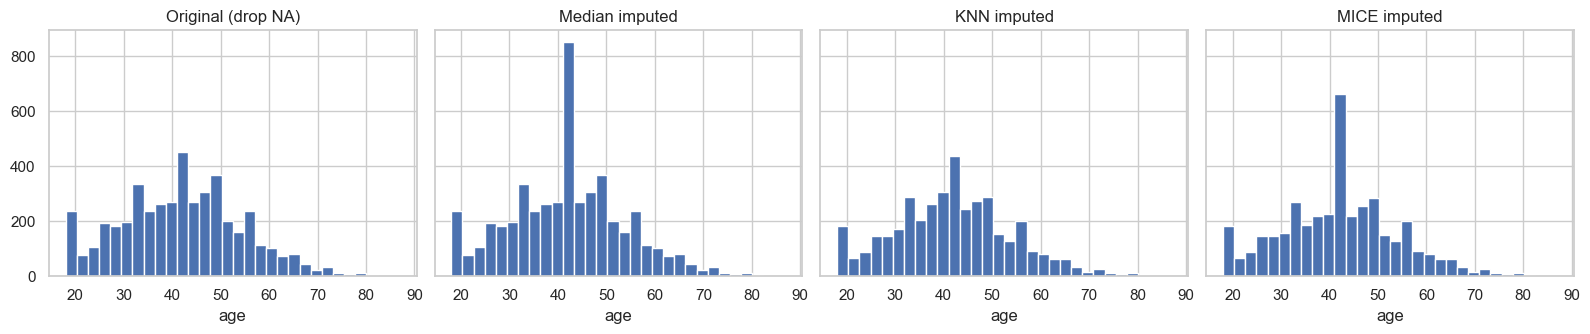

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

axes[0].hist(df["age"].dropna(), bins=30); axes[0].set_title("Original (drop NA)")

median_age = df["age"].median()
axes[1].hist(df["age"].fillna(median_age), bins=30); axes[1].set_title("Median imputed")

axes[2].hist(X_train_knn["age"], bins=30);  axes[2].set_title("KNN imputed")
axes[3].hist(X_train_mice["age"], bins=30); axes[3].set_title("MICE imputed")

for a in axes: a.set_xlabel("age")
plt.tight_layout(); plt.show()

## 9. Cheat sheet — when to use what

| Situation | Use |
|-----------|-----|
| Tiny missing % (<1%), MCAR | drop |
| Numeric, skewed, fast pipeline | median |
| Categorical | mode (most_frequent) or `"Missing"` as its own category |
| Features correlated, more compute OK | KNN |
| Mixed columns, want best quality | IterativeImputer (MICE) |
| Missingness might be informative | add a `_was_missing` indicator |

## Exercise
1. Build a `ColumnTransformer` that median-imputes numeric and mode-imputes categorical,
   then trains a `LogisticRegression` and reports test accuracy.
2. Repeat with `KNNImputer` for numeric. Did accuracy change? Why or why not?